# 1. Business understanding

Business Objective:

 - To analyze patient healthcare records and understand the factors associated with stroke occurrence.

Expected Outcome:

 - To clean, validate, and prepare the healthcare dataset so that it becomes structured, reliable, and ready for further analysis.

# 2. Data understanding

Import libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Load the dataset

In [45]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

Number of rows and columns

In [46]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5110
Number of columns: 12


Features available

In [47]:
print("Features available:")
print(df.columns.tolist())

Features available:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


Target variable

In [48]:
target_variable = "stroke"

print("Target variable:", target_variable)

Target variable: stroke


Numerical Columns

In [49]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


In [50]:
['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

Categorical Columns

In [51]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [52]:
['gender',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status']

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# 3. Dataframe exploration

Shape analysis

In [53]:
print("Dataset shape:", df.shape)

Dataset shape: (5110, 12)


Data types

In [54]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Column information

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Summary statistics

In [56]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Overall structure

In [57]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [58]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


# 4. Data cleaning

Missing values

Missing value count

In [59]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Missing value report

In [60]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_report

,Missing Values,Missing Percentage
id,0,0.000000
gender,0,0.000000
age,0,0.000000
hypertension,0,0.000000
heart_disease,0,0.000000
ever_married,0,0.000000
work_type,0,0.000000
Residence_type,0,0.000000
avg_glucose_level,0,0.000000
bmi,201,3.933464


Handle missing BMI

In [61]:
bmi_median = df["bmi"].median()

df["bmi"] = df["bmi"].fillna(bmi_median)

print("Missing BMI values after cleaning:", df["bmi"].isnull().sum())

Missing BMI values after cleaning: 0


Cleaning Decision:

 - The BMI column contained 201 missing values. Since BMI is a numerical variable, the missing values were replaced with the median BMI value. Median imputation was selected because it is less affected by extreme values.

4.2 Duplicate Records

Check duplicate records

In [62]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


Duplicate Analysis Report

In [63]:
duplicate_report = pd.DataFrame({
    "Check": ["Duplicate Rows"],
    "Count": [df.duplicated().sum()]
})

duplicate_report

,Check,Count
0,Duplicate Rows,0


Cleaning Decision:

 - No duplicate records were found in the dataset. Therefore, no duplicate records were removed.

4.3 Incorrect Data Types

Check data types

In [64]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Check expected numerical columns

In [65]:
for column in numerical_columns:
    print(column, ":", pd.api.types.is_numeric_dtype(df[column]))

id : True
age : True
hypertension : True
heart_disease : True
avg_glucose_level : True
bmi : True
stroke : True


Check expected categorical columns

In [66]:
for column in categorical_columns:
    print(column, ":", df[column].dtype)

gender : object
ever_married : object
work_type : object
Residence_type : object
smoking_status : object


Cleaning Decision:

 - The dataset columns have appropriate data types for their respective contents. No data type conversion was required.

4.4 Invalid Values

Check binary variables

In [67]:
print("Hypertension values:", df["hypertension"].unique())
print("Heart disease values:", df["heart_disease"].unique())
print("Stroke values:", df["stroke"].unique())

Hypertension values: [0 1]
Heart disease values: [1 0]
Stroke values: [1 0]


Check age

In [68]:
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Minimum age: 0.08
Maximum age: 82.0


Check glucose

In [69]:
print("Minimum glucose level:", df["avg_glucose_level"].min())
print("Maximum glucose level:", df["avg_glucose_level"].max())

Minimum glucose level: 55.12
Maximum glucose level: 271.74


Check BMI

In [70]:
print("Minimum BMI:", df["bmi"].min())
print("Maximum BMI:", df["bmi"].max())

Minimum BMI: 10.3
Maximum BMI: 97.6


Count invalid binary values

In [71]:
print("Invalid hypertension values:",
      (~df["hypertension"].isin([0, 1])).sum())

print("Invalid heart disease values:",
      (~df["heart_disease"].isin([0, 1])).sum())

print("Invalid stroke values:",
      (~df["stroke"].isin([0, 1])).sum())

Invalid hypertension values: 0
Invalid heart disease values: 0
Invalid stroke values: 0


4.5 Inconsistent Categorical Values

Check categorical values

In [72]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 gender
['Male' 'Female' 'Other']

 ever_married
['Yes' 'No']

 work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

 Residence_type
['Urban' 'Rural']

 smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


Categorical value counts

In [73]:
for column in categorical_columns:
    print("\n---", column, "---")
    print(df[column].value_counts())


--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


Cleaning decision — Markdown cell

Cleaning Decision:

 - The categorical columns were checked for inconsistent values. The categories are consistent with the dataset structure, so no categorical values were changed.

# 5. Outlier Analysis

 - This is still Sprint 1 because your Sprint 1 specifically asks for outlier analysis.

 - We will use both:

 - Statistical method → IQR
Visualization → Box plots

 - We are not doing general EDA here.

Select continuous variables

In [74]:
continuous_columns = [
    "age",
    "avg_glucose_level",
    "bmi"
]

IQR outlier analysis

In [75]:
outlier_report = []

for column in continuous_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_report.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_limit,
        upper_limit,
        outlier_count
    ])

outlier_report = pd.DataFrame(
    outlier_report,
    columns=[
        "Column",
        "Q1",
        "Q3",
        "IQR",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count"
    ]
)

outlier_report

,Column,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,age,25.000,61.00,36.000,-29.0000,115.0000,0
1,avg_glucose_level,77.245,114.09,36.845,21.9775,169.3575,627
2,bmi,23.800,32.80,9.000,10.3000,46.3000,126


Outlier visualization

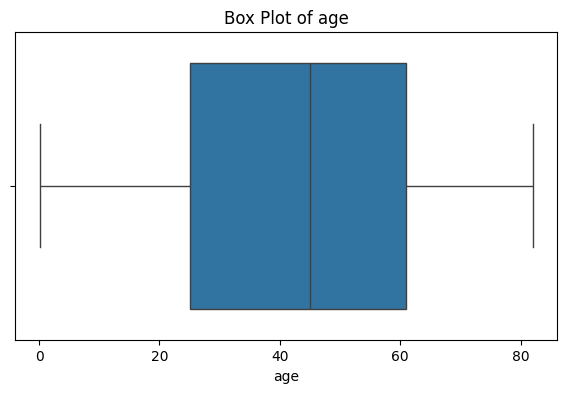

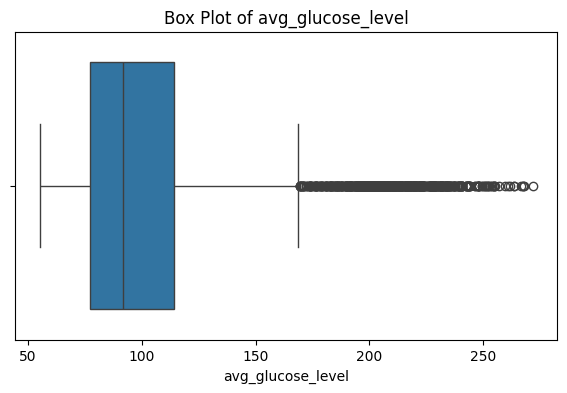

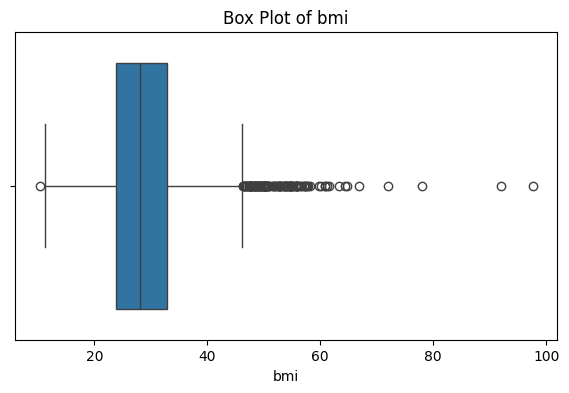

In [76]:
for column in continuous_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

Decide how to handle outliers

 - Outlier Decision:

 - - The outliers in avg_glucose_level and BMI are retained.

 - Reason:
 - - These values may represent genuine patient health conditions rather than incorrect data. Removing them could remove clinically meaningful observations from the dataset.

 - No transformation or removal is performed.

# 6. Data Validation

Validate missing values

In [77]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


Validate duplicate records

In [78]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


Validate data types

In [79]:
print(df.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Validate binary values

In [80]:
print("Invalid hypertension values:",
      (~df["hypertension"].isin([0, 1])).sum())

print("Invalid heart disease values:",
      (~df["heart_disease"].isin([0, 1])).sum())

print("Invalid stroke values:",
      (~df["stroke"].isin([0, 1])).sum())

Invalid hypertension values: 0
Invalid heart disease values: 0
Invalid stroke values: 0


Final validation summary

In [81]:
validation_summary = pd.DataFrame({
    "Validation Check": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Invalid Hypertension Values",
        "Invalid Heart Disease Values",
        "Invalid Stroke Values"
    ],

    "Result": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (~df["hypertension"].isin([0, 1])).sum(),
        (~df["heart_disease"].isin([0, 1])).sum(),
        (~df["stroke"].isin([0, 1])).sum()
    ]
})

validation_summary

,Validation Check,Result
0,Rows,5110
1,Columns,12
2,Missing Values,0
3,Duplicate Rows,0
4,Invalid Hypertension Values,0
5,Invalid Heart Disease Values,0
6,Invalid Stroke Values,0


# 7. Initial Business Observations

Initial Business Observations:

1. The dataset contains 5,110 patient records and 12 variables.

2. The dataset contains demographic, health, lifestyle, and patient-related information.

3. The target variable is stroke.

4. BMI was the only feature with missing values, containing 201 missing records before cleaning.

5. No duplicate records were found.

6. The numerical and categorical columns have appropriate data types.

7. No invalid values were found in the binary health-related variables.

8. Outliers were identified mainly in average glucose level and BMI.

9. The identified outliers were retained because they may represent genuine patient health conditions.

10. After cleaning and validation, the dataset is ready for further analysis.

# print 1 Deliverables

Save Cleaned Dataset

In [82]:
df.to_csv("stroke_data_cleaned_sprint1.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Save Missing Value Report

In [83]:
missing_report.to_csv("missing_value_report.csv", index=False)

print("Missing value report saved successfully.")

Missing value report saved successfully.


Save Duplicate Analysis Report

In [84]:
duplicate_report.to_csv("duplicate_analysis_report.csv", index=False)

print("Duplicate analysis report saved successfully.")

Duplicate analysis report saved successfully.


Save Outlier Analysis Report

In [85]:
outlier_report.to_csv("outlier_analysis_report.csv", index=False)

print("Outlier analysis report saved successfully.")

Outlier analysis report saved successfully.


Save Data Validation

In [86]:
validation_summary.to_csv("data_validation_summary.csv", index=False)

print("Data validation summary saved successfully.")

Data validation summary saved successfully.
